In [1]:
from kan import *
import torch.nn as nn
import torch.optim as optim
import torch
from helper_lin import get_all_data
class LassoBrainKAN(nn.Module):
    def __init__(self, hidden_dim=32):
        super(LassoBrainKAN, self).__init__()
        # width=[100, hidden_dim, 1] maps to your 100 inputs, hidden_dim, and 1 output
        # grid and k define the spline granularity and order (3 is standard)
        self.kan = KAN(width=[100, hidden_dim, 1], grid=3, k=3, seed=42) 
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Pass input through KAN, then apply Sigmoid for binary classification
        x = self.kan(x)
        return self.sigmoid(x)

In [2]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.model_selection import StratifiedKFold
import torch
import matplotlib.pyplot as plt
import numpy as np

def evaluate_kan_pipeline(X_avg, y_avg, hidden_dim=32, l1_lambda=0.005, lr=0.01, epochs=100):
    all_test_preds = []
    all_test_labels = []
    all_test_probs = []
    all_fold_losses = []
    all_fold_val_losses = []
    all_fold_accuracies = []
    all_fold_val_accuracies = []

    # 5-Fold Stratified CV
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    print(f"Starting Leakage-Free 5-Fold CV with KAN...")

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_avg, y_avg)):
        # 1. SPLIT DATA FIRST
        X_train_fold, X_test_fold = X_avg[train_idx], X_avg[test_idx]
        y_train_fold, y_test_fold = y_avg[train_idx], y_avg[test_idx]

        # 2. FEATURE SELECTION (Fit ONLY on training data)
        selector = SelectKBest(score_func=f_classif, k=100)
        X_train_reduced = selector.fit_transform(X_train_fold, y_train_fold)
        X_test_reduced = selector.transform(X_test_fold) # Transform only!

        # 3. SCALING (Fit ONLY on training data)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_reduced)
        X_test_scaled = scaler.transform(X_test_reduced) # Transform only!

        # Convert to Tensors
        X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
        y_train_t = torch.tensor(y_train_fold, dtype=torch.float32).view(-1, 1)
        X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
        y_test_t = torch.tensor(y_test_fold, dtype=torch.float32).view(-1, 1)

        # Initialize KAN Model
        model = LassoBrainKAN(hidden_dim=hidden_dim) 
        criterion = torch.nn.BCELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        # Track losses and accuracies for this fold
        fold_losses = []
        fold_val_losses = []
        fold_accuracies = []
        fold_val_accuracies = []

        # Train 
        model.train()
        for epoch in range(epochs):
            optimizer.zero_grad()
            outputs = model(X_train_t)
            bce_loss = criterion(outputs, y_train_t)
            
            # KAN generalized L1 penalty
            l1_penalty = sum(torch.norm(p, 1) for p in model.parameters() if p.dim() > 1)
            total_loss = bce_loss + (l1_lambda * l1_penalty)
            
            total_loss.backward()
            optimizer.step()
            
            # Track training loss
            fold_losses.append(total_loss.item())
            
            # Calculate training accuracy
            train_preds = (outputs > 0.5).float().numpy().flatten()
            train_acc = accuracy_score(y_train_fold, train_preds)
            fold_accuracies.append(train_acc)
            
            # Calculate validation loss and accuracy
            model.eval()
            with torch.no_grad():
                val_outputs = model(X_test_t)
                val_bce_loss = criterion(val_outputs, y_test_t)
                val_l1_penalty = sum(torch.norm(p, 1) for p in model.parameters() if p.dim() > 1)
                val_total_loss = val_bce_loss + (l1_lambda * val_l1_penalty)
                fold_val_losses.append(val_total_loss.item())
                
                val_preds = (val_outputs > 0.5).float().numpy().flatten()
                val_acc = accuracy_score(y_test_fold, val_preds)
                fold_val_accuracies.append(val_acc)
            model.train()

        all_fold_losses.append(fold_losses)
        all_fold_val_losses.append(fold_val_losses)
        all_fold_accuracies.append(fold_accuracies)
        all_fold_val_accuracies.append(fold_val_accuracies)

        # Evaluate on the unseen Test Fold
        model.eval()
        with torch.no_grad():
            test_probs_t = model(X_test_t)
            preds = (test_probs_t > 0.5).float().numpy().flatten()
            
            all_test_probs.extend(test_probs_t.numpy().flatten())
            all_test_preds.extend(preds)
            all_test_labels.extend(y_test_fold)
        
        print(f"Fold {fold+1} complete. Final Loss: {fold_losses[-1]:.4f}, Final Val Loss: {fold_val_losses[-1]:.4f}")

    final_acc = accuracy_score(all_test_labels, all_test_preds)
    print(f"\nHonest K-Fold Accuracy: {final_acc * 100:.2f}%")
    
    return all_test_labels, all_test_probs, all_test_preds, all_fold_losses, all_fold_val_losses, all_fold_accuracies, all_fold_val_accuracies

X_avg, y_avg = get_all_data()
all_test_labels, all_test_probs, all_test_preds, all_fold_losses, all_fold_val_losses, all_fold_accuracies, all_fold_val_accuracies = evaluate_kan_pipeline(X_avg, y_avg)

Starting Leakage-Free 5-Fold CV with KAN...
checkpoint directory created: ./model
saving model version 0.0
Fold 1 complete. Final Loss: 27.5353, Final Val Loss: 29.0911
checkpoint directory created: ./model
saving model version 0.0
Fold 2 complete. Final Loss: 27.5364, Final Val Loss: 28.6869
checkpoint directory created: ./model
saving model version 0.0
Fold 3 complete. Final Loss: 27.5366, Final Val Loss: 28.6482
checkpoint directory created: ./model
saving model version 0.0
Fold 4 complete. Final Loss: 27.5040, Final Val Loss: 28.4266
checkpoint directory created: ./model
saving model version 0.0
Fold 5 complete. Final Loss: 27.4854, Final Val Loss: 28.1670

Honest K-Fold Accuracy: 56.67%


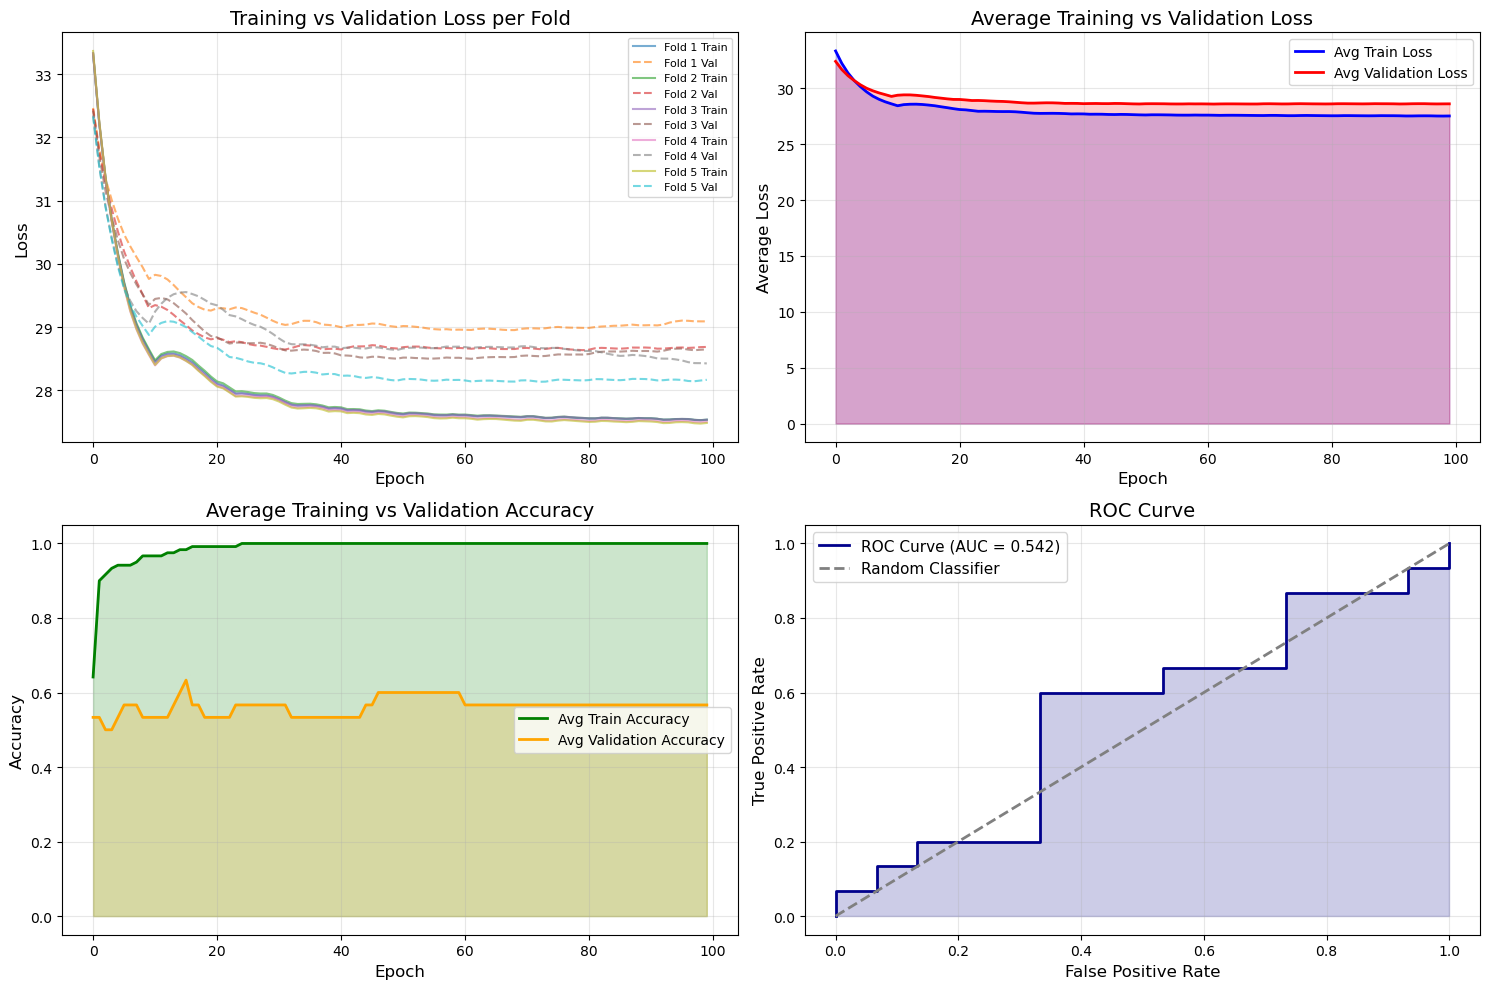

In [3]:
# Plot training and validation curves
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Individual Fold Loss Curves
for fold, (losses, val_losses) in enumerate(zip(all_fold_losses, all_fold_val_losses)):
    axes[0, 0].plot(losses, label=f'Fold {fold+1} Train', alpha=0.6, linestyle='-')
    axes[0, 0].plot(val_losses, label=f'Fold {fold+1} Val', alpha=0.6, linestyle='--')
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Training vs Validation Loss per Fold', fontsize=14)
axes[0, 0].legend(fontsize=8, loc='best')
axes[0, 0].grid(True, alpha=0.3)

# 2. Average Loss Across Folds
avg_loss = [np.mean([all_fold_losses[f][e] for f in range(len(all_fold_losses))]) 
            for e in range(len(all_fold_losses[0]))]
avg_val_loss = [np.mean([all_fold_val_losses[f][e] for f in range(len(all_fold_val_losses))]) 
                for e in range(len(all_fold_val_losses[0]))]
axes[0, 1].plot(avg_loss, color='blue', linewidth=2, label='Avg Train Loss')
axes[0, 1].plot(avg_val_loss, color='red', linewidth=2, label='Avg Validation Loss')
axes[0, 1].fill_between(range(len(avg_loss)), avg_loss, alpha=0.2, color='blue')
axes[0, 1].fill_between(range(len(avg_val_loss)), avg_val_loss, alpha=0.2, color='red')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Average Loss', fontsize=12)
axes[0, 1].set_title('Average Training vs Validation Loss', fontsize=14)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Average Accuracy Across Folds
avg_acc = [np.mean([all_fold_accuracies[f][e] for f in range(len(all_fold_accuracies))]) 
           for e in range(len(all_fold_accuracies[0]))]
avg_val_acc = [np.mean([all_fold_val_accuracies[f][e] for f in range(len(all_fold_val_accuracies))]) 
               for e in range(len(all_fold_val_accuracies[0]))]
axes[1, 0].plot(avg_acc, color='green', linewidth=2, label='Avg Train Accuracy')
axes[1, 0].plot(avg_val_acc, color='orange', linewidth=2, label='Avg Validation Accuracy')
axes[1, 0].fill_between(range(len(avg_acc)), avg_acc, alpha=0.2, color='green')
axes[1, 0].fill_between(range(len(avg_val_acc)), avg_val_acc, alpha=0.2, color='orange')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Accuracy', fontsize=12)
axes[1, 0].set_title('Average Training vs Validation Accuracy', fontsize=14)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. ROC Curve
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(all_test_labels, all_test_probs)
roc_auc = auc(fpr, tpr)
axes[1, 1].plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[1, 1].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
axes[1, 1].fill_between(fpr, tpr, alpha=0.2, color='darkblue')
axes[1, 1].set_xlabel('False Positive Rate', fontsize=12)
axes[1, 1].set_ylabel('True Positive Rate', fontsize=12)
axes[1, 1].set_title('ROC Curve', fontsize=14)
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()